# Centralized Fine-Tuning Results

Compares three checkpoints:
- **round10_global** — FL global model after 10 rounds (baseline)
- **stage1_head_only** — after centralized fine-tuning with backbone + neck frozen
- **stage2_neck_head** — after centralized fine-tuning with only backbone frozen

Each checkpoint is evaluated on two splits:
- **client2_val** — held-out validation from client 2
- **central_test** — centralized test set

In [31]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── config ────────────────────────────────────────────────────────────────────
JSON_PATH  = Path("results.json")   # adjust if needed
SAVE_DIR   = Path("figures")                      # set to None to only display
DPI        = 150
# ──────────────────────────────────────────────────────────────────────────────

if SAVE_DIR:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

with open(JSON_PATH) as f:
    raw = json.load(f)

# ── friendly labels ───────────────────────────────────────────────────────────
STAGE_LABELS = {
    "round10_global":  "FL Global\n(round 10)",
    "stage1_head_only": "Head-only\nfine-tune",
    "stage2_neck_head": "Neck+Head\nfine-tune",
}
SPLIT_LABELS = {
    "client2_val":  "Client-2 Val",
    "central_test": "Central Test",
}
METRICS = ["map50", "precision", "recall", "f1"]
METRIC_LABELS = {"map50": "mAP50", "precision": "Precision",
                 "recall": "Recall", "f1": "F1"}

stages = list(raw.keys())
splits = list(next(iter(raw.values())).keys())
print("Stages:", stages)
print("Splits:", splits)

Stages: ['round10_global', 'stage1_head_only', 'stage2_neck_head']
Splits: ['client2_val', 'central_test']


In [32]:
# Recompute precision / recall / F1 from per_class_confusion (source of truth).
# The top-level values in the JSON were computed at a different threshold and are inconsistent.
for stage, splits in raw.items():
    for split, d in splits.items():
        conf = d["per_class_confusion"]
        tp = sum(c["tp"] for c in conf.values())
        fp = sum(c["fp"] for c in conf.values())
        fn = sum(c["fn"] for c in conf.values())
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)
                     if (precision + recall) > 0 else 0.0)
        d["precision"] = precision
        d["recall"]    = recall
        d["f1"]        = f1

## 1  All metrics — grouped bar chart

Each cluster of bars is one metric; colours represent stages. Two subplots: one per evaluation split.

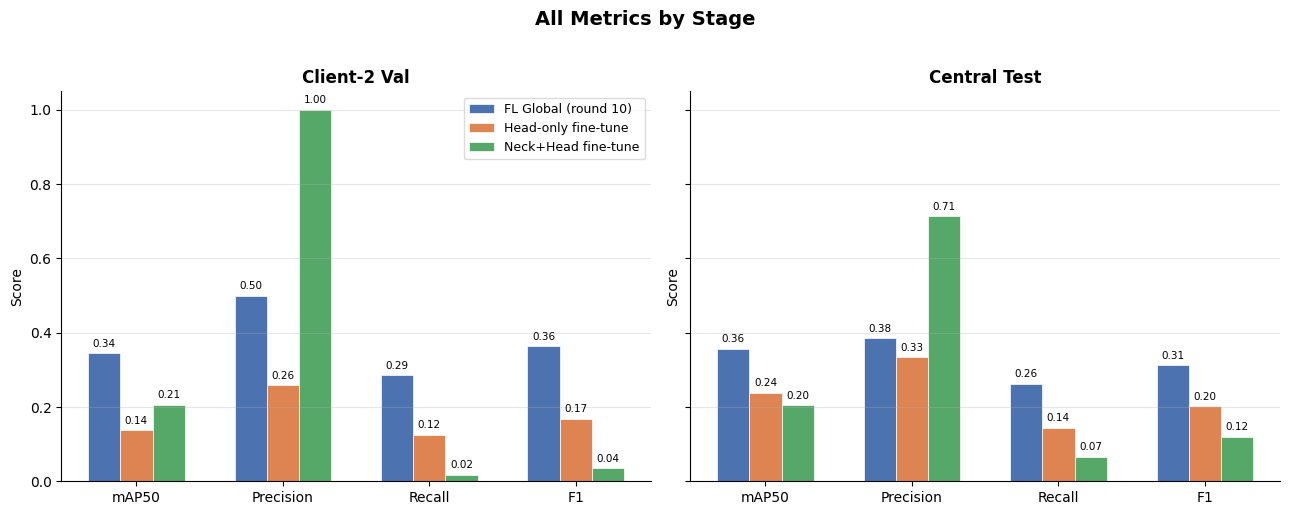

In [33]:
STAGE_COLORS = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, split in zip(axes, splits):
    x = np.arange(len(METRICS))
    n = len(stages)
    width = 0.22
    offsets = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * width

    for i, (stage, color) in enumerate(zip(stages, STAGE_COLORS)):
        vals = [raw[stage][split][m] for m in METRICS]
        bars = ax.bar(x + offsets[i], vals, width,
                      label=STAGE_LABELS[stage].replace("\n", " "),
                      color=color, edgecolor="white", linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS])
    ax.set_ylim(0, 1.05)
    ax.set_title(SPLIT_LABELS[split], fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    if ax == axes[0]:
        ax.legend(fontsize=9, framealpha=0.7)

fig.suptitle("All Metrics by Stage", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
if SAVE_DIR:
    fig.savefig(SAVE_DIR / "01_all_metrics.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 2  mAP50 progression

Shows whether each fine-tuning stage improves or hurts mAP50 relative to the FL baseline.

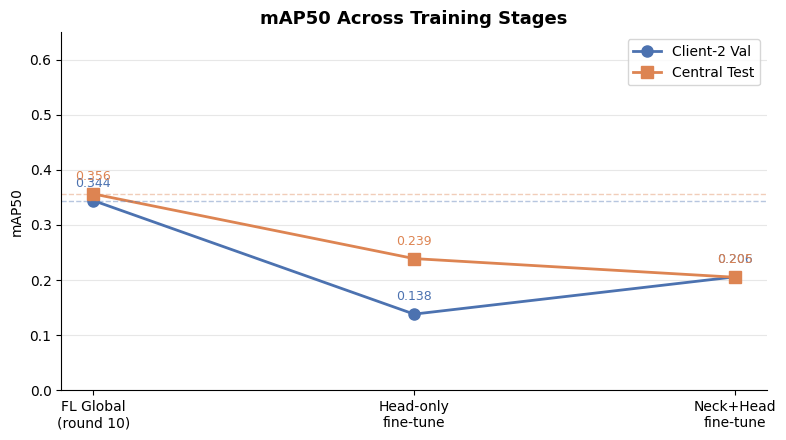

In [34]:
SPLIT_COLORS  = ["#4C72B0", "#DD8452"]
SPLIT_MARKERS = ["o", "s"]

fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(stages))
for split, color, marker in zip(splits, SPLIT_COLORS, SPLIT_MARKERS):
    vals = [raw[stage][split]["map50"] for stage in stages]
    ax.plot(x, vals, marker=marker, linewidth=2, markersize=8,
            color=color, label=SPLIT_LABELS[split])
    for xi, v in zip(x, vals):
        ax.annotate(f"{v:.3f}", (xi, v), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=9, color=color)

# shade area between FL baseline and fine-tune stages
baseline = {split: raw[stages[0]][split]["map50"] for split in splits}
for split, color in zip(splits, SPLIT_COLORS):
    ax.axhline(baseline[split], linestyle="--", linewidth=1, color=color, alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels([STAGE_LABELS[s] for s in stages])
ax.set_ylabel("mAP50")
ax.set_ylim(0, 0.65)
ax.set_title("mAP50 Across Training Stages", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
if SAVE_DIR:
    fig.savefig(SAVE_DIR / "02_map50_progression.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 3  Precision–Recall trade-off

Each point is one (stage, split) pair. The dashed lines are iso-F1 contours. 
This reveals whether a stage gains recall at the cost of precision or vice versa.

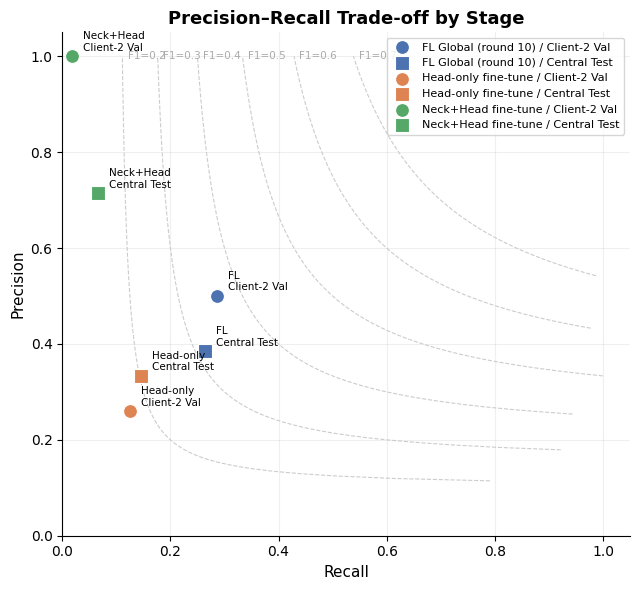

In [35]:
fig, ax = plt.subplots(figsize=(6.5, 6))

# iso-F1 contours
p_grid = np.linspace(0.01, 1, 200)
for f1_target in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    r_grid = f1_target * p_grid / (2 * p_grid - f1_target)
    mask = (r_grid >= 0) & (r_grid <= 1)
    ax.plot(r_grid[mask], p_grid[mask], "--", color="#cccccc", linewidth=0.8)
    if mask.any():
        ax.text(r_grid[mask][-1] + 0.01, p_grid[mask][-1],
                f"F1={f1_target:.1f}", fontsize=7.5, color="#aaaaaa", va="center")

for i, stage in enumerate(stages):
    for j, split in enumerate(splits):
        r = raw[stage][split]["recall"]
        p = raw[stage][split]["precision"]
        marker = SPLIT_MARKERS[j]
        color  = STAGE_COLORS[i]
        label  = (STAGE_LABELS[stage].replace("\n", " ") + " / " + SPLIT_LABELS[split]
                  if True else None)
        ax.scatter(r, p, marker=marker, s=100, color=color,
                   edgecolors="white", linewidth=0.8, zorder=3, label=label)
        ax.annotate(f"{STAGE_LABELS[stage].split()[0]}\n{SPLIT_LABELS[split]}",
                    (r, p), textcoords="offset points",
                    xytext=(8, 4), fontsize=7.5)

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_title("Precision–Recall Trade-off by Stage", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", framealpha=0.8)
ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
if SAVE_DIR:
    fig.savefig(SAVE_DIR / "03_pr_tradeoff.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 4  Radar chart — metric profiles per stage

Each polygon is one stage. A rounder, larger polygon is better overall. 
The shape shows which stages are well-balanced vs biased toward precision or recall.

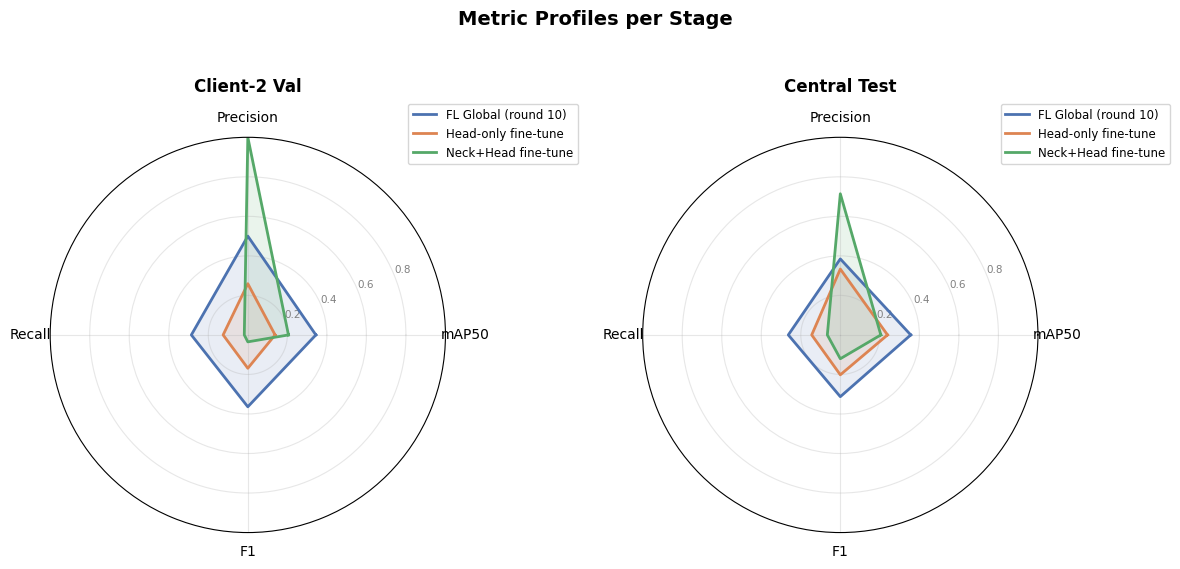

In [36]:
radar_metrics = ["map50", "precision", "recall", "f1"]
radar_labels  = [METRIC_LABELS[m] for m in radar_metrics]
n_metrics = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5),
                          subplot_kw=dict(polar=True))

for ax, split in zip(axes, splits):
    for stage, color in zip(stages, STAGE_COLORS):
        vals = [raw[stage][split][m] for m in radar_metrics]
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=2, color=color,
                label=STAGE_LABELS[stage].replace("\n", " "))
        ax.fill(angles, vals, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=7.5, color="grey")
    ax.set_title(SPLIT_LABELS[split], fontsize=12, fontweight="bold", pad=14)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8.5)
    ax.grid(alpha=0.3)

fig.suptitle("Metric Profiles per Stage", fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
if SAVE_DIR:
    fig.savefig(SAVE_DIR / "04_radar.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 5  Val vs Test gap per stage

Shows how well each checkpoint generalises: a large gap between client-2 val and central test suggests overfitting to the local client distribution.

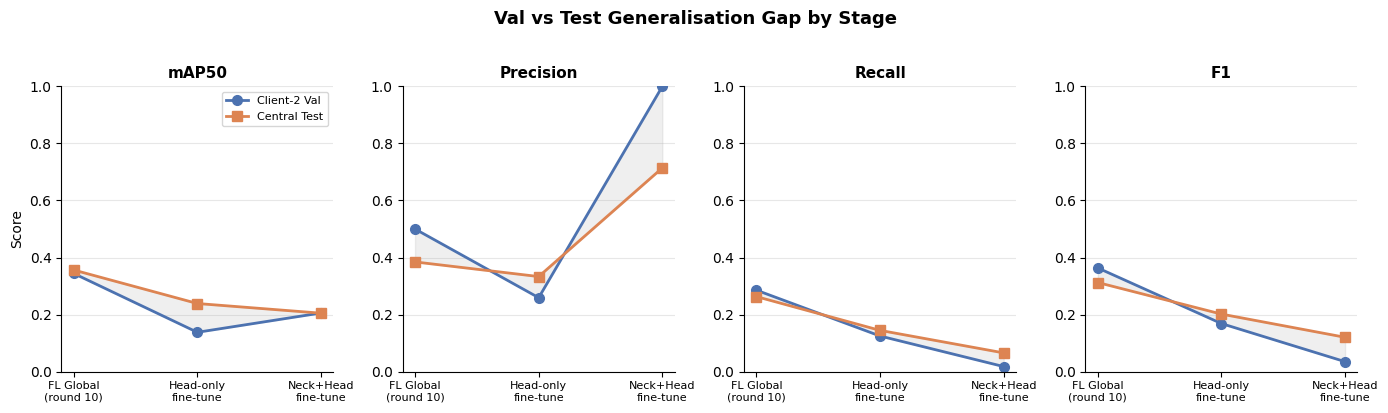

In [37]:
fig, axes = plt.subplots(1, len(METRICS), figsize=(14, 4), sharey=False)

x = np.arange(len(stages))

for ax, metric in zip(axes, METRICS):
    val_vals  = [raw[s]["client2_val"][metric]  for s in stages]
    test_vals = [raw[s]["central_test"][metric] for s in stages]

    ax.plot(x, val_vals,  "o-", color=SPLIT_COLORS[0], linewidth=2,
            markersize=7, label="Client-2 Val")
    ax.plot(x, test_vals, "s-", color=SPLIT_COLORS[1], linewidth=2,
            markersize=7, label="Central Test")
    ax.fill_between(x, val_vals, test_vals, alpha=0.12, color="grey")

    ax.set_xticks(x)
    ax.set_xticklabels([STAGE_LABELS[s] for s in stages], fontsize=8)
    ax.set_title(METRIC_LABELS[metric], fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel("Score")
        ax.legend(fontsize=8)

fig.suptitle("Val vs Test Generalisation Gap by Stage", fontsize=13,
             fontweight="bold", y=1.02)
fig.tight_layout()
if SAVE_DIR:
    fig.savefig(SAVE_DIR / "05_val_test_gap.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 6  Summary table

In [38]:
import pandas as pd

rows = []
for stage in stages:
    for split in splits:
        d = raw[stage][split]
        rows.append({
            "Stage":     STAGE_LABELS[stage].replace("\n", " "),
            "Split":     SPLIT_LABELS[split],
            "mAP50":     d["map50"],
            "Precision": d["precision"],
            "Recall":    d["recall"],
            "F1":        d["f1"],
            "n_images":  d["n_images"],
        })

df = pd.DataFrame(rows)
display(df.style
    .format({"mAP50": "{:.3f}", "Precision": "{:.3f}",
             "Recall": "{:.3f}", "F1": "{:.3f}"})
    .background_gradient(subset=["mAP50", "F1"], cmap="YlGn")
    .set_caption("Results summary")
)

,Stage,Split,mAP50,Precision,Recall,F1,n_images
0,FL Global (round 10),Client-2 Val,0.344,0.500,0.286,0.364,30
1,FL Global (round 10),Central Test,0.356,0.385,0.263,0.312,45
2,Head-only fine-tune,Client-2 Val,0.138,0.259,0.125,0.169,30
3,Head-only fine-tune,Central Test,0.239,0.333,0.145,0.202,45
4,Neck+Head fine-tune,Client-2 Val,0.206,1.000,0.018,0.035,30
5,Neck+Head fine-tune,Central Test,0.205,0.714,0.066,0.120,45


## 7  TP / FP / FN per class

Counts of true positives, false positives, and false negatives broken down by defect class, stage, and evaluation split.

In [39]:
rows = []
for stage in stages:
    for split in splits:
        conf = raw[stage][split]["per_class_confusion"]
        for cls, counts in conf.items():
            rows.append({
                "Stage":  STAGE_LABELS[stage].replace("\n", " "),
                "Split":  SPLIT_LABELS[split],
                "Class":  cls,
                "TP":     counts["tp"],
                "FP":     counts["fp"],
                "FN":     counts["fn"],
            })

df_conf = pd.DataFrame(rows)

# pivot to (Stage × Split) columns, Class rows
pivot = df_conf.pivot_table(
    index="Class",
    columns=["Stage", "Split"],
    values=["TP", "FP", "FN"],
    aggfunc="first",
)
pivot = pivot.reindex(columns=pd.MultiIndex.from_product(
    [["TP", "FP", "FN"],
     [STAGE_LABELS[s].replace("\n", " ") for s in stages],
     [SPLIT_LABELS[sp] for sp in splits]],
    names=["Metric", "Stage", "Split"],
))

display(pivot.style
    .format("{:.0f}", na_rep="-")
    .background_gradient(subset=pd.IndexSlice[:, pd.IndexSlice["TP", :, :]], cmap="Greens")
    .background_gradient(subset=pd.IndexSlice[:, pd.IndexSlice["FP", :, :]], cmap="Reds")
    .background_gradient(subset=pd.IndexSlice[:, pd.IndexSlice["FN", :, :]], cmap="Oranges")
    .set_caption("TP / FP / FN per class  (green = TP, red = FP, orange = FN)")
)